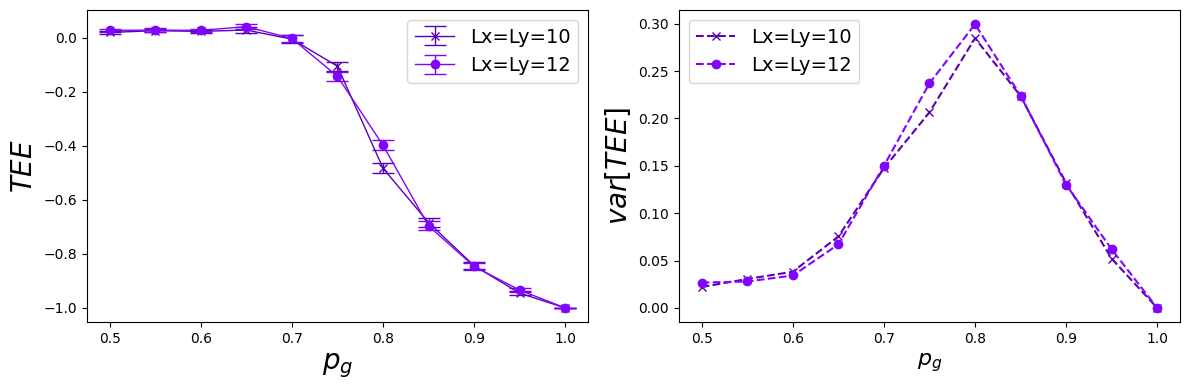

In [5]:
from __future__ import print_function, division
import sys,os
# line 4 and line 5 below are for development purposes and ca be removed
import numpy as np # generic math functions
import matplotlib.pyplot as plt # plotting library
import pylab
import time
import sys
import math
import matplotlib.cm as cm

np.set_printoptions(precision=3)
np.set_printoptions(suppress=True)

#################
data_set = {}
p_list=[]
L_list=[10,12]
markers = ['x', 'o', '^', 's', '*', 'H', 'D']
#fig, ax = plt.subplots(1,2,figsize=(12,4))
Np=11
########
########
cmap = plt.colormaps['gnuplot']
for ip in range(Np):
    pg=0.5*ip/(Np-1)+0.5
    p_list=np.append(p_list,pg)
fig, ax = plt.subplots(1,2,figsize=(12,4))
for tmp_i in range(len(L_list)):
    Lx=L_list[tmp_i]
    Ly=L_list[tmp_i]
    data_set= np.load("Lx="+"{:}".format(Lx)+".npz")
    #print(Lx,Ly)
    TEE_ave=[]
    TEE_error=[]
    TEE_var=[]
    for ip in range(Np):
        # stabilizer matrix
        #pdp=ip/(Np-1)
        pg=0.5*ip/(Np-1)+0.5
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_p="+"{:.2f}TEE".format(pg)
        #print(data_set)
        TEE_list=data_set[key1]
        ###
        #print(R2_csrlist)
        TEE_aved=np.mean(TEE_list)
        TEE_errord=np.std(TEE_list, ddof=1)/ np.sqrt(len(TEE_list))
        TEE_vard=np.var(TEE_list)
        #print(R2csr_list)
        ###
        TEE_ave=np.append(TEE_ave,TEE_aved)
        TEE_error=np.append(TEE_error,TEE_errord)
        TEE_var=np.append(TEE_var,TEE_vard)
    #fig, ax = plt.subplots(figsize=(6,4))
    ax[0].set_xlabel(r'$p_g$',fontsize=20)  # x軸ラベル
    ax[0].set_ylabel(r'$TEE$',fontsize=20)  # y軸ラベル
    ax[0].errorbar(p_list,TEE_ave,yerr=TEE_error,color=cmap((tmp_i+1)/8), marker=markers[tmp_i], capthick=1, markersize=6, capsize=8, lw=1,label='Lx=Ly='+"{:}".format(Lx))
    ax[0].legend(loc=0,fontsize=14)    # 凡例
    ax[1].set_xlabel(r'$p_g$',fontsize=16)  # x軸ラベル
    ax[1].set_ylabel(r'$var[TEE]$',fontsize=20)  # y軸ラベル
    ax[1].plot(p_list,TEE_var,linestyle='dashed',color=cmap((tmp_i+1)/8), marker=markers[tmp_i],label='Lx=Ly='+"{:}".format(Lx))
    ax[1].legend(loc=0,fontsize=14)    # 凡例
fig.tight_layout()  # レイアウトの設定
plt.show()